In [3]:
# Block 0 — imports
import numpy as np
from PIL import Image
import torch

PATH = "./ave-mujica-resized.jpeg"   # set this
S    = 32                 # resize to S×S; keep small so adjacency/graph stay renderable

In [4]:
# Block 1 — load → array
img = Image.open(PATH).convert("RGB").resize((S, S), Image.BILINEAR)
img = np.asarray(img, dtype=np.float32) / 255.0   # (H, W, 3), scaled to [0,1]
H, W, C = img.shape
N = H * W
print("img.shape:", img.shape, "| N nodes:", N, "| C:", C)
# (32, 32, 3) | N nodes: 1024 | C: 3

img.shape: (32, 32, 3) | N nodes: 1024 | C: 3


In [5]:
# Block 2 — pixels → nodes, row-major (node_id = y*W + x)
X = img.reshape(N, C)          # (N, 3)  row-major flatten matches label f"{x}-{y}"
node_id = np.arange(N).reshape(H, W)   # node_id[y, x] = y*W + x
print("X.shape:", X.shape)     # (1024, 3)

X.shape: (1024, 3)


In [6]:
# Block 3 — vectorized grid edges, no dense N×N ever allocated
ys, xs = np.mgrid[0:H, 0:W]                # each (H, W)
offsets = [(dy, dx) for dy in (-1,0,1) for dx in (-1,0,1) if (dy,dx) != (0,0)]  # 8

src, dst = [], []
for dy, dx in offsets:
    ny, nx = ys + dy, xs + dx
    valid  = (ny >= 0) & (ny < H) & (nx >= 0) & (nx < W)   # drop off-grid neighbors
    src.append(node_id[ys[valid], xs[valid]])
    dst.append(node_id[ny[valid], nx[valid]])

edge_index = np.stack([np.concatenate(src), np.concatenate(dst)], axis=0)  # (2, E)
edge_index = torch.as_tensor(edge_index, dtype=torch.long)
X = torch.as_tensor(X, dtype=torch.float32)

print("edge_index.shape:", tuple(edge_index.shape))   # (2, E)
print("E (directed):", edge_index.shape[1])

edge_index.shape: (2, 7812)
E (directed): 7812


undirected edges drawn: 3906


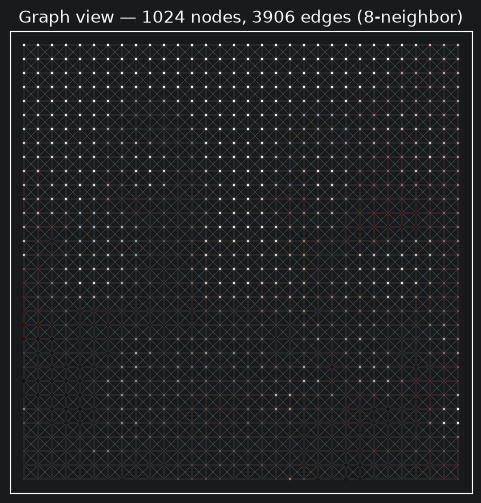

In [7]:
# Block 5 — graph view: nodes on grid (colored by RGB) + edges
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# node positions from row-major id: pos[i] = (x, y),  x = i % W, y = i // W
ids  = np.arange(N)
xpos = ids % W
ypos = ids // W

# undirected edge set: keep each pair once (src < dst)
ei   = edge_index.numpy()
mask = ei[0] < ei[1]
s, d = ei[0][mask], ei[1][mask]

segs = np.stack([np.stack([xpos[s], ypos[s]], axis=1),
                 np.stack([xpos[d], ypos[d]], axis=1)], axis=1)  # (E_und, 2, 2)
print("undirected edges drawn:", segs.shape[0])

cols = X.numpy()            # (N, 3) RGB in [0,1] → node facecolors
ms   = max(4, 1200 // N)    # shrink markers as N grows

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(LineCollection(segs, colors="0.6", linewidths=0.3, alpha=0.5, zorder=1))
ax.scatter(xpos, ypos, c=cols, s=ms, edgecolors="k", linewidths=0.2, zorder=2)

ax.set_xlim(-1, W); ax.set_ylim(-1, H)
ax.set_aspect("equal")
ax.invert_yaxis()          # row 0 at top → matches image orientation
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Graph view — {N} nodes, {segs.shape[0]} edges (8-neighbor)")
plt.show()